In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from netam.common import heavy_chain_shim
from netam.framework import load_crepe
from netam.sequences import translate_sequence, AA_STR_SORTED
from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify

figures_dir = localify("FIGURES_DIR")
os.makedirs("_output", exist_ok=True)


In [ ]:


title = '4HWB_2|Chain B[auth H]|Fab heavy chain|Homo sapiens (9606)'
heavy_wt = 'AEVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLEWMGVIYPGDSYTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARMPNWGSFDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCDKTHL'
grab_positions = ['N97', 'Y52', 'D54', 'Y56', 'W33']

#title = '5TZ2_1|Chain A[auth H]|C47B222 Fab Heavy Chain|Homo sapiens (9606)'
#heavy_wt = 'EVQLVQSGAEVKKPGESLKISCKGSGYSFTDYWIGWVRQMPGKGLEWMGIIYPGDSDTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAVYYCARVGRFASHQLDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCHHHHHH'
#grab_positions = ['W33', 'D56', 'Y52', 'D54']

#title = '6MI2_1|Chains A, C[auth D]|Utomilumab Fab heavy chain|Homo sapiens (9606)'
#heavy_wt = 'EVQLVQSGAEVKKPGESLRISCKGSGYSFSTYWISWVRQMPGKGLEWMGKIYPGDSYTNYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARGYGIFDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCAAAHHHHHHHH'
#grab_positions = ['W33', 'Y52', 'Y56', 'D54']



In [143]:
title = '5TZ2_1|Chain A[auth H]|C47B222 Fab Heavy Chain|Homo sapiens (9606)'
heavy_wt = 'EVQLVQSGAEVKKPGESLKISCKGSGYSFTDYWIGWVRQMPGKGLEWMGIIYPGDSDTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAVYYCARVGRFASHQLDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCHHHHHH'
grab_positions = ['W33', 'D56', 'Y52', 'D54']

In [132]:
title = '6MI2_1|Chains A, C[auth D]|Utomilumab Fab heavy chain|Homo sapiens (9606)'
heavy_wt = 'EVQLVQSGAEVKKPGESLRISCKGSGYSFSTYWISWVRQMPGKGLEWMGKIYPGDSYTNYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARGYGIFDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCAAAHHHHHHHH'
grab_positions = ['W33', 'Y52', 'Y56', 'D54']

In [144]:
def assign_wt(df, wt_seq, value):
    for idx, aa in enumerate(wt_seq):
        df.loc[aa, idx+1] = value

def df_of_arr(arr):
    return pd.DataFrame(arr, columns=range(1, arr.shape[1] + 1), index=list(AA_STR_SORTED))

In [145]:
# Load DASM model
crepe = load_crepe(localify("DASM_TRAINED_MODELS_DIR/dasm_4m-v1jaffeCC+v1tangCC-joint"))
#crepe.model.train()
crepe = heavy_chain_shim(crepe)
[dasm_heavy] = crepe([heavy_wt])
log_dasm_heavy = (np.log(dasm_heavy).T)
log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
assign_wt(log_dasm_heavy_df, heavy_wt, np.nan)

/tmp/ipykernel_6113/1396345626.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_dasm_heavy = (np.log(dasm_heavy).T)


In [146]:
def zero_centered_cb_min_center_max(df):
    data_min = df.min().min()
    data_max = df.max().max()
    assert data_min < 0 and data_max > 0
    return data_min, 0, data_max

def make_heatmap(df, ax, colorbar_label):
    _ = dms_style_heatmap(
        df, 
        ax=ax, 
        cb_min_center_max=zero_centered_cb_min_center_max(df), 
        plot_aa_order=list("YWFLIVAMKRHDESTNQPGC"),
        colorbar_label=colorbar_label)

EVQLVQSGAEVKKPGESLKISCKGSGYSFTDYWIGWVRQMPGKGLEWMGIIYPGDSDTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAVYYCARVGRFASHQLDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCHHHHHH


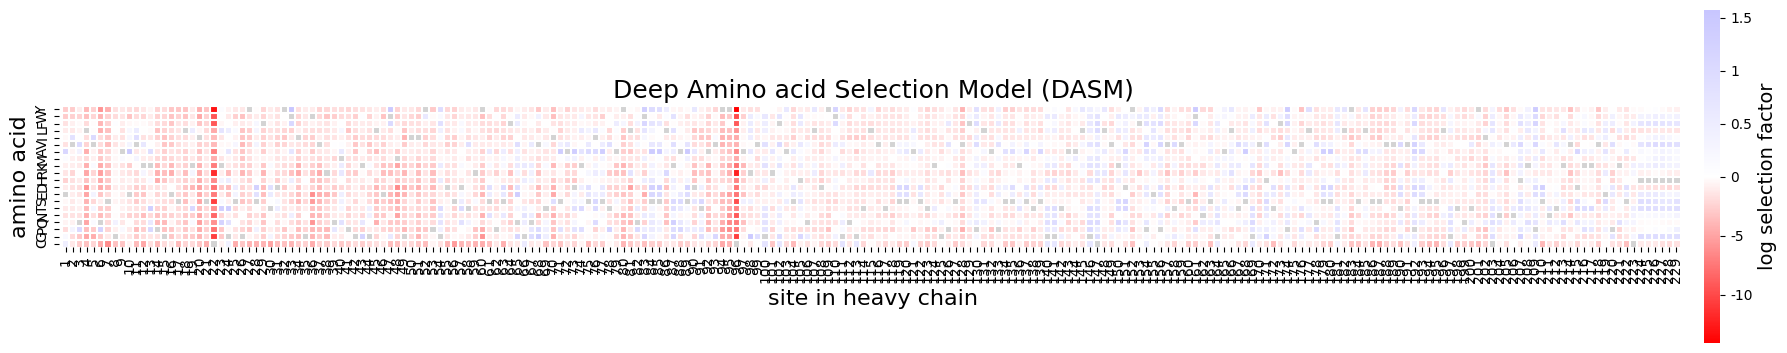

In [147]:
# Saving a version of the heatmap for an early slide
fig, ax = plt.subplots(1, 1, figsize=(18, 4))

print(heavy_wt)

make_heatmap(log_dasm_heavy_df, ax, "log selection factor")
ax.set_title('Deep Amino acid Selection Model (DASM)', fontsize=18)
ax.set_xlabel('site in heavy chain', fontsize=16)
ax.set_ylabel('amino acid', fontsize=16)
plt.tight_layout()

#fig.savefig(f"{figures_dir}/koenig2017_sequence_dasm_heatmap.svg")

In [148]:
[dasm_heavy] = crepe([heavy_wt])
dasm_heavy

tensor([[2.9851, 1.5679, 0.3337,  ..., 0.2028, 0.0575, 0.0608],
        [0.5449, 0.2783, 0.2112,  ...,    nan, 0.0714, 0.0630],
        [1.4136, 0.0624, 0.1614,  ..., 2.6793, 0.0912, 0.3833],
        ...,
        [1.4031, 0.1850, 0.1596,  ..., 2.5896, 1.5086, 0.7225],
        [1.2900, 0.1521, 0.1187,  ..., 2.3814, 1.3679, 0.5105],
        [1.2268, 0.1916, 0.1546,  ..., 2.3404, 1.4138, 0.4579]])

/tmp/ipykernel_6113/727850871.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_dasm_heavy = (np.log(dasm_heavy).T)


In [ ]:
def tensor_to_dataframe(tensor):
    # Flatten the tensor to 1D
    if isinstance(tensor, torch.Tensor):
        values = tensor.flatten().numpy()
    else:  # TensorFlow tensor
        values = tensor.numpy().flatten()
    
    # Create numeric positions (simple integers)
    positions = np.arange(len(values))
    
    # Create DataFrame - IMPORTANT: Using simple integers, not lists
    df = pd.DataFrame({
        'position': positions,  # This will be integers, not lists
        'value': values
    })
    
    return df


def plot_grab_dnsm(heavy_seq, title, grab_positions):

    # Load DNSM model
    crepe = load_crepe(localify("DNSM_TRAINED_MODELS_DIR/dnsm_1m-v1jaffe+v1tang-joint"))
    crepe = heavy_chain_shim(crepe)
    [dnsm_heavy] = crepe([heavy_seq])
    log_dnsm_heavy = (np.log(dnsm_heavy).T)
    df = tensor_to_dataframe(log_dnsm_heavy)

    # Create the plot with all data
    ax = df.plot(x='position', y='value', kind='bar', figsize=(18, 4), legend=False)
    df[df.position.isin([int(i[1:]) for i in grab_positions])].plot(x='position', y='value', kind='scatter', figsize=(18, 4), color='red', ax=ax)

    # Get the current tick labels
    locs, labels = plt.xticks()

    # Create new labels that only show every 5th position
    new_labels = [str(df['position'][i]) if i % 5 == 0 else '' for i in range(len(df))]

    # Add custom vertical grid for every second position
    for i in range(0, len(df), 2):
        ax.axvline(x=i, color='lightgray', linestyle='-', alpha=0.5, zorder=0)

    # Apply the new labels
    plt.xticks(locs, new_labels)

    plt.xlabel('Position')
    plt.ylabel('DNSM log selection factor')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [161]:
heavy_wt = 'AEVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLEWMGVIYPGDSYTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARMPNWGSFDYWGQGTLVTVSS'
heavy_wt[33]

'W'

/tmp/ipykernel_6113/60141170.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_dasm_heavy = (np.log(dasm_heavy).T)


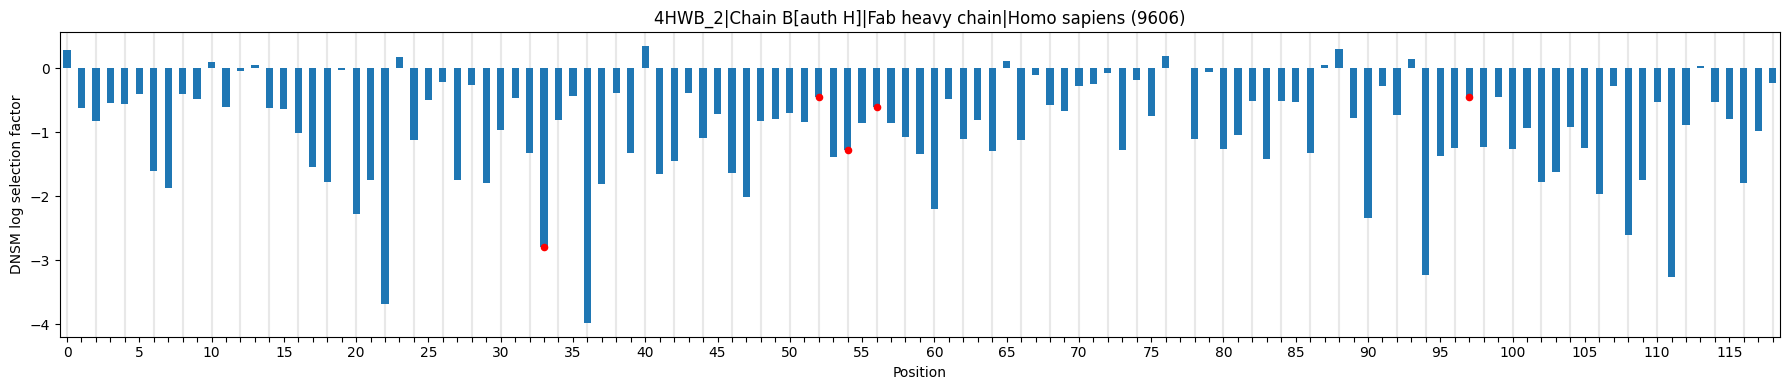

/tmp/ipykernel_6113/60141170.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_dasm_heavy = (np.log(dasm_heavy).T)


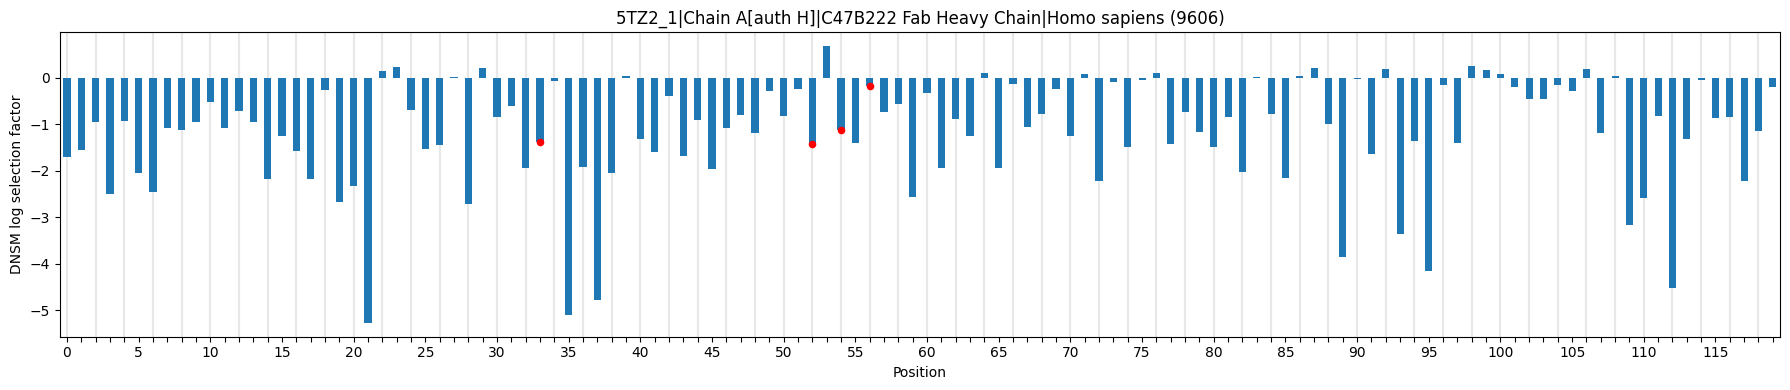

/tmp/ipykernel_6113/60141170.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_dasm_heavy = (np.log(dasm_heavy).T)


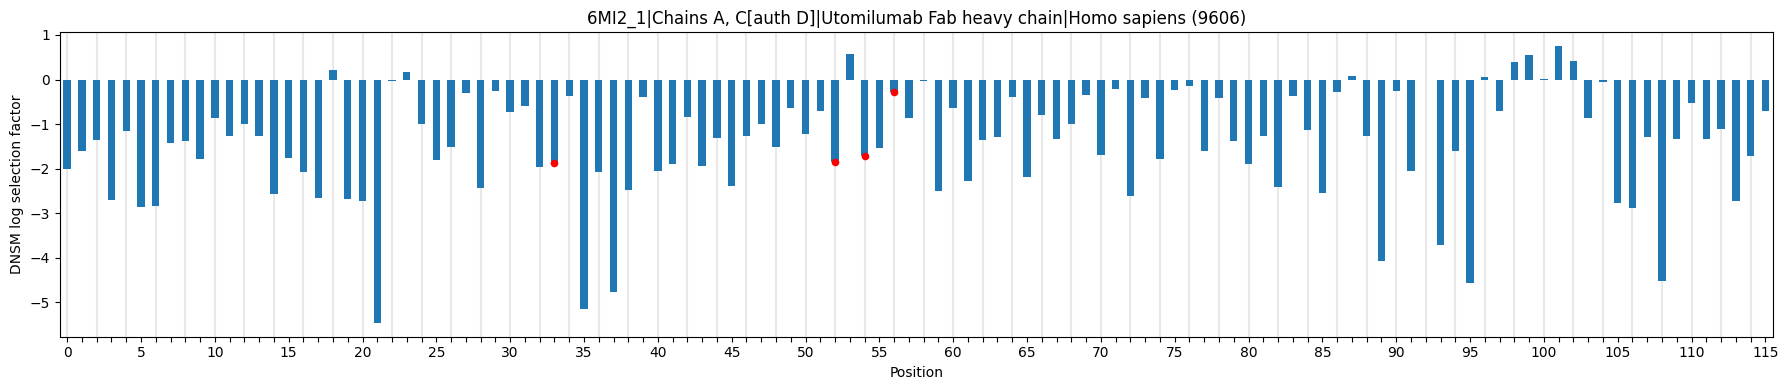

In [ ]:


title = '4HWB_2|Chain B[auth H]|Fab heavy chain|Homo sapiens (9606)'
#heavy_wt = 'AEVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLEWMGVIYPGDSYTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARMPNWGSFDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCDKTHL'
heavy_wt = 'AEVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLEWMGVIYPGDSYTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARMPNWGSFDYWGQGTLVTVSS'

grab_positions = ['N97', 'Y52', 'D54', 'Y56', 'W33']
plot_grab_dnsm(heavy_wt, title, grab_positions)


title = '5TZ2_1|Chain A[auth H]|C47B222 Fab Heavy Chain|Homo sapiens (9606)'
#heavy_wt = 'EVQLVQSGAEVKKPGESLKISCKGSGYSFTDYWIGWVRQMPGKGLEWMGIIYPGDSDTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAVYYCARVGRFASHQLDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCHHHHHH'
heavy_wt = 'EVQLVQSGAEVKKPGESLKISCKGSGYSFTDYWIGWVRQMPGKGLEWMGIIYPGDSDTRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAVYYCARVGRFASHQLDYWGQGTLVTVSS'

grab_positions = ['W33', 'D56', 'Y52', 'D54']
plot_grab_dnsm(heavy_wt, title, grab_positions)

heavy_wt = "EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS"

title = '6MI2_1|Chains A, C[auth D]|Utomilumab Fab heavy chain|Homo sapiens (9606)'
#heavy_wt = 'EVQLVQSGAEVKKPGESLRISCKGSGYSFSTYWISWVRQMPGKGLEWMGKIYPGDSYTNYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARGYGIFDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCAAAHHHHHHHH'

heavy_wt = 'EVQLVQSGAEVKKPGESLRISCKGSGYSFSTYWISWVRQMPGKGLEWMGKIYPGDSYTNYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARGYGIFDYWGQGTLVTVSS'
grab_positions = ['W33', 'Y52', 'Y56', 'D54']
plot_grab_dnsm(heavy_wt, title, grab_positions)



In [ ]:
# make sure DNSM is run correctly - V
# did I trim correctly to only Vh? Is the model trained on only Vh?
# IMGT numbering, Chothia numbering
# ask for solvent accessibility databse from Dave (make sure it's relative solvent accessibility) - V
# get the naive seqs for these sequences and try those out (Erick's notebook)